# Parte 1 — Análise exploratória com APIs externas

Clima (Open-Meteo), feriados (Nager.Date), padrões geoespaciais e demanda do 1746 (2023–2024).

## Instalando bibliotecas necessárias

In [112]:
!pip install seaborn

## Importando bibliotecas necessárias

In [113]:
import basedosdados as bd
import pandas as pd
import requests
import seaborn as sns

### Configurações

In [114]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Base de dados de chamados

### Baixando dados da base

In [115]:
df_chamados = bd.read_sql(
    "SELECT * FROM `datario.adm_central_atendimento_1746.chamado` WHERE data_particao >= '2023-01-01' AND data_particao <= '2024-12-31' ORDER BY RAND() LIMIT 500",
    billing_project_id="desafio-pic",
)

Downloading: 100%|██████████|


### Análise de colunas 

In [116]:
df_chamados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   id_chamado                        500 non-null    object             
 1   id_origem_ocorrencia              500 non-null    object             
 2   data_inicio                       500 non-null    datetime64[us]     
 3   data_fim                          494 non-null    datetime64[us]     
 4   id_bairro                         344 non-null    object             
 5   id_territorialidade               344 non-null    object             
 6   id_logradouro                     344 non-null    object             
 7   numero_logradouro                 317 non-null    Int64              
 8   id_unidade_organizacional         500 non-null    object             
 9   nome_unidade_organizacional       500 non-null    object         

### Análise de dados duplicados
Nenhum registro duplicado foi encontrado

In [117]:
df_chamados.duplicated().sum()

np.int64(0)

### Análise de dados nulos
Foram encontradas as seguintes colunas com dados nulos:
- numero_logradouro: 28
- longitude: 423
- latitude: 28
- data_alvo_diagnostico: 1000
- data_real_diagnostico: 1000
- justificativa_status: 965

In [118]:
print(
    [
        (col, df_chamados[col].isna().sum())
        for col in df_chamados.columns[df_chamados.isna().any()].tolist()
    ]
)

[('data_fim', np.int64(6)), ('id_bairro', np.int64(156)), ('id_territorialidade', np.int64(156)), ('id_logradouro', np.int64(156)), ('numero_logradouro', np.int64(183)), ('longitude', np.int64(269)), ('latitude', np.int64(269)), ('data_alvo_finalizacao', np.int64(108)), ('data_alvo_diagnostico', np.int64(488)), ('data_real_diagnostico', np.int64(487)), ('tempo_prazo', np.int64(108)), ('prazo_unidade', np.int64(108)), ('prazo_tipo', np.int64(108)), ('justificativa_status', np.int64(471))]


### Análise descritiva dos dados

In [119]:
df_chamados.describe().T

,count,mean,min,25%,50%,75%,max,std
data_inicio,500,2024-01-06 22:34:50.552000,2023-01-03 00:23:36,2023-07-19 05:30:07.250000,2024-01-21 20:59:21.500000,2024-06-24 18:16:06.750000,2024-12-20 15:23:15,NaN
data_fim,494,2024-01-23 22:10:20.012145,2023-01-03 13:56:55,2023-07-28 11:10:51.250000,2024-01-31 05:39:28.500000,2024-07-04 13:56:42.250000,2025-10-14 10:09:44,NaN
numero_logradouro,317.0,431.466877,0.0,30.0,136.0,411.0,15900.0,1150.105129
longitude,231.0,-43.325296,-43.68937,-43.38165,-43.292476,-43.22092,-43.171405,0.129557
latitude,231.0,-22.914164,-23.023821,-22.954002,-22.912151,-22.880215,-22.789356,0.054902
data_alvo_finalizacao,392,2024-01-22 21:09:31.234694,2023-01-04 19:10:00,2023-07-04 15:39:00,2024-02-05 20:20:00,2024-07-18 15:28:30,2025-10-13 16:58:17,NaN
data_alvo_diagnostico,12,2023-09-01 23:07:20,2023-02-28 17:15:00,2023-07-14 03:16:30,2023-09-09 10:54:30,2023-10-19 17:29:15,2024-04-28 08:12:00,NaN
data_real_diagnostico,13,2023-07-23 01:08:10.692307,2023-03-16 09:07:53,2023-05-22 10:45:13,2023-07-28 10:56:32,2023-09-01 12:27:29,2024-04-22 18:29:28,NaN
tempo_prazo,392.0,16.923469,1.0,3.0,10.0,24.0,240.0,31.962402
reclamacoes,500.0,0.006,0.0,0.0,0.0,0.0,1.0,0.077304


### Tratamento de dados nulos
Considerando as análises iniciais, considerei substituir os valores nulos de:
- colunas Int ou Float pela mediana
- colunas de latitude ou longitude pela moda
- colunas de datas não serão alteradas, pois todos os registros são nulos e até o momento não serão usados
- colunas object não serão alteradas, pois até o momento não serão usadas

#### Coluna numero_logradouro

In [120]:
df_chamados["numero_logradouro"] = df_chamados["numero_logradouro"].fillna(
    df_chamados["numero_logradouro"].median().round(0)
)
df_chamados["numero_logradouro"].isna().sum()

np.int64(0)

### Coluna longitude

In [121]:
longitude_moda = df_chamados["longitude"].mode()
if not longitude_moda.empty:
    df_chamados["longitude"] = df_chamados["longitude"].fillna(
        value=float(longitude_moda.iloc[0]),
    )
df_chamados["longitude"].isna().sum()

np.int64(0)

#### Coluna latitude

In [122]:
latitude_moda = df_chamados["latitude"].mode()
if not latitude_moda.empty:
    df_chamados["latitude"] = df_chamados["latitude"].fillna(
        value=float(latitude_moda.iloc[0]),
    )
df_chamados["latitude"].isna().sum()

np.int64(0)

### Tratamento de datas
Para fazer as requisições à API do Open-Meteo é preciso ter a data formatada como "YYYY-MM-dd"

#### Coluna data_inicio

In [123]:
df_chamados["data_inicio"] = pd.to_datetime(df_chamados["data_inicio"]).dt.strftime(
    "%Y-%m-%d"
)
df_chamados["data_inicio"].head()

0    2023-07-19
1    2024-05-25
2    2023-02-20
3    2023-11-15
4    2023-06-20
Name: data_inicio, dtype: object

#### Coluna data_fim

In [124]:
df_chamados["data_fim"] = pd.to_datetime(df_chamados["data_fim"]).dt.strftime(
    "%Y-%m-%d"
)
df_chamados["data_fim"].head()

0    2023-07-19
1    2024-05-25
2    2023-04-07
3    2023-11-15
4    2023-06-22
Name: data_fim, dtype: object

## Baixando dados da API Open-Meteo

## Acessando a API

In [125]:
from typing import Any


# df = df_chamados.copy()

API_URL = "https://archive-api.open-meteo.com/v1/archive"
DAILY_FIELDS = "temperature_2m_max,temperature_2m_min,precipitation_sum"
TIMEOUT_SECONDS = 20

# Colunas de saída
for col in [
    "temperatura_maxima",
    "temperatura_minima",
    "precipitacao",
]:
    df_chamados[col] = pd.NA


def is_missing_coords(row: pd.Series) -> bool:
    return bool(pd.isna([row["latitude"], row["longitude"]]).any())


def build_weather_params(row: pd.Series) -> dict[str, Any]:
    start_date = pd.Timestamp(row["data_inicio"]).strftime("%Y-%m-%d")
    return {
        "latitude": float(row["latitude"]),
        "longitude": float(row["longitude"]),
        "start_date": start_date,
        "end_date": start_date,
        "daily": DAILY_FIELDS,
        "timezone": "auto",
    }


def fetch_daily_temperatures(
    session: requests.Session,
    params: dict[str, Any],
) -> tuple[list[Any], list[Any], list[Any]]:
    response = session.get(API_URL, params=params, timeout=TIMEOUT_SECONDS)
    response.raise_for_status()

    daily = response.json().get("daily", {})
    max_values = daily.get("temperature_2m_max", [])
    min_values = daily.get("temperature_2m_min", [])
    precipitacao = daily.get("precipitation_sum", [])
    return max_values, min_values, precipitacao


session = requests.Session()
for index, row in df_chamados.iterrows():
    if is_missing_coords(row):
        continue

    params = build_weather_params(row)

    try:
        max_values, min_values, precipitacao = fetch_daily_temperatures(session, params)
    except requests.RequestException:
        continue

    df_chamados.loc[index, "temperatura_maxima"] = (
        max_values[0] if max_values else pd.NA
    )
    df_chamados.loc[index, "temperatura_minima"] = (
        min_values[0] if min_values else pd.NA
    )
    df_chamados.loc[index, "precipitacao"] = precipitacao[0] if precipitacao else pd.NA


df_chamados[
    [
        "temperatura_maxima",
        "temperatura_minima",
        "precipitacao",
    ]
].head(20)

,temperatura_maxima,temperatura_minima,precipitacao
0,22.0,18.6,9.7
1,25.0,20.0,2.7
2,27.7,21.9,0.1
3,30.0,24.2,0.5
4,24.9,13.4,0.0
5,27.7,22.1,7.1
6,26.3,23.3,1.0
7,28.3,22.7,1.1
8,31.5,20.8,0.0
9,29.8,22.8,0.0


## Analisando a correlação entre os chamados e as condições climáticas

### Agrupando os dados

In [126]:
df_chamados_agrupados = (
    df_chamados
    .groupby(["tipo", "data_inicio"])
    .agg({
        "tipo": "count", 
        "temperatura_maxima": "median",
        "temperatura_minima": "median",
        "precipitacao": "median"
    })
    .rename(columns={"tipo": "total"})
    .reset_index()
)
df_chamados_agrupados

,tipo,data_inicio,total,temperatura_maxima,temperatura_minima,precipitacao
0,Alimentação Popular,2023-03-15,1,27.1,22.3,1.1
1,Alimentos e estabelecimentos de ensino,2024-06-13,1,29.0,14.9,0.0
2,Alvará,2023-01-19,1,32.0,22.5,2.8
3,Alvará,2023-04-11,1,26.9,18.7,0.0
4,Alvará,2023-08-12,1,30.8,21.4,0.0
...,...,...,...,...,...,...
482,Ônibus,2024-04-18,1,25.5,21.9,5.1
483,Ônibus,2024-05-25,1,25.0,21.1,2.6
484,Ônibus,2024-07-25,1,26.3,15.2,0.0
485,Ônibus,2024-10-31,1,24.4,18.0,1.1


### Calculando a correlação

In [127]:
resultado = []

for tipo in df_chamados_agrupados["tipo"].unique():
    subset = df_chamados_agrupados[df_chamados_agrupados["tipo"] == tipo]

    if subset["total"].nunique() > 1:
        resultado.append({
            "tipo": tipo,
            "corr_temp_max": subset["total"].corr(subset["temperatura_maxima"]),
            "corr_temp_min": subset["total"].corr(subset["temperatura_minima"]),
            "corr_chuva": subset["total"].corr(subset["precipitacao"]),
        })

df_corr = pd.DataFrame(resultado)
df_corr

,tipo,corr_temp_max,corr_temp_min,corr_chuva
0,Cadastro Único,0.119727,0.113746,-0.061483
1,Clínicas da Família (CF),0.402390,0.113236,-0.325784
2,Drenagem e Saneamento,0.213123,-0.055484,-0.079510
3,Estacionamento irregular,-0.032192,-0.141929,-0.118470
4,Iluminação Pública,0.110284,0.005884,-0.066021
5,Pavimentação,-0.155391,-0.171167,-0.110646
6,Remoção Gratuita,-0.229774,-0.357895,-0.085659
7,Ônibus,0.360834,0.428869,-0.152560


### Análise de correlação 

Como interpretar as correlações
- menor ou igual a 0 (sem relação)
- 0.3-0.5 (moderada)
- maior que 0.5 (forte)

Chamados relacionados a ****

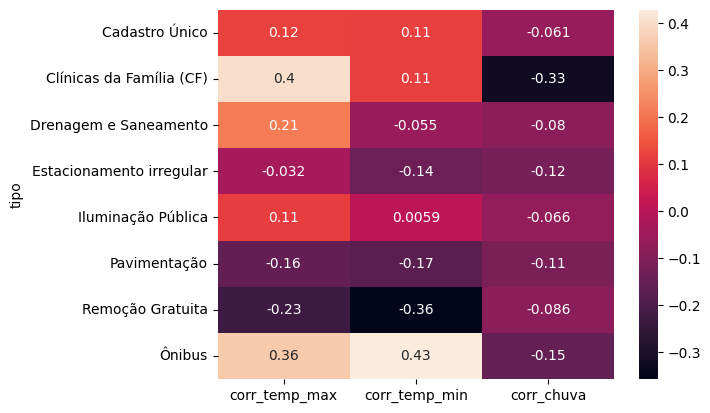

In [128]:
if df_corr.empty:
    print("Sem dados suficientes para calcular correlação por tipo.")
else:
    sns.heatmap(df_corr.set_index("tipo"), annot=True)